# Moons Across Seeds And Surrogate Types

This notebook tests the moons dataset across multiple random seeds and surrogate architectures.

This notebook is part of the experimental pipeline for the paper 'Where Can I Trust You? Teacher-Surrogate Disagreement is Spatially Structured'.

In [1]:
%pip install numpy pandas matplotlib scikit-learn torch -q



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Moons Dataset with Seed Variations

We load the classic Two Moons dataset and initialize variables to run training loops across dozens of random seeds to ensure statistical significance.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


In [3]:
BASE_SEED = 42
np.random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)

# CPU is safest and fast enough for these small experiments on Mac.
DEVICE = "cpu"
print("Using device:", DEVICE)


Using device: cpu


### Training Across Architectures and Seeds

We train MLP teachers and a variety of surrogate models across all random seeds, controlling for initialization variance.

In [4]:
class TeacherMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_teacher(X_train, y_train, seed=42, epochs=500, batch_size=64, lr=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)

    model = TeacherMLP().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

    return model


def teacher_probs(model, X):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs


### Fidelity Evaluation

We now extract the predictions from both the teacher and the surrogate models to compute globally aggregated and locality-aware fidelity metrics.

In [5]:
def fit_surrogate(name, X_train, teacher_train_y, teacher_train_p, seed=42):
    """
    Train a surrogate to mimic the teacher, not the ground-truth labels.

    For now, all surrogates mimic hard teacher labels. This keeps the
    comparison simple and makes fidelity = teacher/surrogate label agreement.
    """
    if name == "logistic_regression":
        model = LogisticRegression(max_iter=1000, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "linear_svm_calibrated":
        base = LinearSVC(max_iter=5000, random_state=seed)
        model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_2":
        model = DecisionTreeClassifier(max_depth=2, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "decision_tree_depth_4":
        model = DecisionTreeClassifier(max_depth=4, random_state=seed)
        model.fit(X_train, teacher_train_y)
        return model

    if name == "small_mlp_surrogate":
        model = MLPClassifier(
            hidden_layer_sizes=(8,),
            activation="relu",
            solver="adam",
            max_iter=2000,
            random_state=seed,
        )
        model.fit(X_train, teacher_train_y)
        return model

    raise ValueError(f"Unknown surrogate: {name}")


def surrogate_probs(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    # Fallback for classifiers that expose only decision_function.
    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


In [6]:
def compute_metrics(y_true, teacher_p, surrogate_p, eps=0.10):
    teacher_y = (teacher_p >= 0.5).astype(int)
    surrogate_y = (surrogate_p >= 0.5).astype(int)

    boundary_mask = np.abs(teacher_p - 0.5) <= eps
    nonboundary_mask = ~boundary_mask

    metrics = {
        "teacher_task_accuracy": accuracy_score(y_true, teacher_y),
        "surrogate_task_accuracy": accuracy_score(y_true, surrogate_y),
        "global_fidelity": accuracy_score(teacher_y, surrogate_y),
        "probability_mse": mean_squared_error(teacher_p, surrogate_p),
        "n_boundary_points": int(boundary_mask.sum()),
        "boundary_fraction": float(boundary_mask.mean()),
    }

    if boundary_mask.sum() > 0:
        metrics["boundary_fidelity"] = accuracy_score(teacher_y[boundary_mask], surrogate_y[boundary_mask])
        metrics["boundary_task_accuracy"] = accuracy_score(y_true[boundary_mask], surrogate_y[boundary_mask])
    else:
        metrics["boundary_fidelity"] = np.nan
        metrics["boundary_task_accuracy"] = np.nan

    if nonboundary_mask.sum() > 0:
        metrics["nonboundary_fidelity"] = accuracy_score(teacher_y[nonboundary_mask], surrogate_y[nonboundary_mask])
    else:
        metrics["nonboundary_fidelity"] = np.nan

    metrics["boundary_gap"] = metrics["global_fidelity"] - metrics["boundary_fidelity"]
    return metrics


In [7]:
def run_one(seed, surrogate_name, eps=0.10, noise=0.25, n_samples=1500):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=seed)
    X = StandardScaler().fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=seed, stratify=y
    )

    teacher = train_teacher(X_train, y_train, seed=seed, epochs=500)

    teacher_train_p = teacher_probs(teacher, X_train)
    teacher_test_p = teacher_probs(teacher, X_test)
    teacher_train_y = (teacher_train_p >= 0.5).astype(int)

    surrogate = fit_surrogate(
        surrogate_name,
        X_train,
        teacher_train_y,
        teacher_train_p,
        seed=seed,
    )
    surrogate_test_p = surrogate_probs(surrogate, X_test)

    metrics = compute_metrics(y_test, teacher_test_p, surrogate_test_p, eps=eps)
    metrics["seed"] = seed
    metrics["surrogate"] = surrogate_name
    metrics["eps"] = eps
    metrics["noise"] = noise
    return metrics


In [8]:
seeds = list(range(10))
surrogates = [
    "logistic_regression",
    "linear_svm_calibrated",
    "decision_tree_depth_2",
    "decision_tree_depth_4",
    "small_mlp_surrogate",
]

eps = 0.10
rows = []

for seed in seeds:
    print(f"Running seed {seed}...")
    for surrogate_name in surrogates:
        row = run_one(seed=seed, surrogate_name=surrogate_name, eps=eps, noise=0.25)
        rows.append(row)

results = pd.DataFrame(rows)
results


Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
Running seed 5...
Running seed 6...
Running seed 7...
Running seed 8...
Running seed 9...


,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,probability_mse,n_boundary_points,boundary_fraction,boundary_fidelity,boundary_task_accuracy,nonboundary_fidelity,boundary_gap,seed,surrogate,eps,noise
0,0.914286,0.840000,0.883810,0.059355,10,0.019048,0.800000,0.300000,0.885437,0.083810,0,logistic_regression,0.1,0.25
1,0.914286,0.840000,0.883810,0.059148,10,0.019048,0.800000,0.300000,0.885437,0.083810,0,linear_svm_calibrated,0.1,0.25
2,0.914286,0.878095,0.929524,0.045969,10,0.019048,0.700000,0.200000,0.933981,0.229524,0,decision_tree_depth_2,0.1,0.25
3,0.914286,0.878095,0.929524,0.036599,10,0.019048,0.700000,0.200000,0.933981,0.229524,0,decision_tree_depth_4,0.1,0.25
4,0.914286,0.840000,0.883810,0.059026,10,0.019048,0.800000,0.300000,0.885437,0.083810,0,small_mlp_surrogate,0.1,0.25
5,0.939048,0.883810,0.899048,0.051914,7,0.013333,0.428571,0.714286,0.905405,0.470476,1,logistic_regression,0.1,0.25
6,0.939048,0.883810,0.899048,0.051653,7,0.013333,0.428571,0.714286,0.905405,0.470476,1,linear_svm_calibrated,0.1,0.25
7,0.939048,0.916190,0.950476,0.033853,7,0.013333,0.571429,0.571429,0.955598,0.379048,1,decision_tree_depth_2,0.1,0.25
8,0.939048,0.916190,0.950476,0.027665,7,0.013333,0.571429,0.571429,0.955598,0.379048,1,decision_tree_depth_4,0.1,0.25
9,0.939048,0.931429,0.984762,0.006244,7,0.013333,0.571429,0.571429,0.990347,0.413333,1,small_mlp_surrogate,0.1,0.25


In [9]:
summary = (
    results
    .groupby("surrogate")
    .agg(
        teacher_task_accuracy_mean=("teacher_task_accuracy", "mean"),
        teacher_task_accuracy_std=("teacher_task_accuracy", "std"),
        surrogate_task_accuracy_mean=("surrogate_task_accuracy", "mean"),
        surrogate_task_accuracy_std=("surrogate_task_accuracy", "std"),
        global_fidelity_mean=("global_fidelity", "mean"),
        global_fidelity_std=("global_fidelity", "std"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        boundary_fidelity_std=("boundary_fidelity", "std"),
        nonboundary_fidelity_mean=("nonboundary_fidelity", "mean"),
        nonboundary_fidelity_std=("nonboundary_fidelity", "std"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_gap_std=("boundary_gap", "std"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
        probability_mse_mean=("probability_mse", "mean"),
    )
    .sort_values("boundary_gap_mean", ascending=False)
)

summary


,teacher_task_accuracy_mean,teacher_task_accuracy_std,surrogate_task_accuracy_mean,surrogate_task_accuracy_std,global_fidelity_mean,global_fidelity_std,boundary_fidelity_mean,boundary_fidelity_std,nonboundary_fidelity_mean,nonboundary_fidelity_std,boundary_gap_mean,boundary_gap_std,boundary_fraction_mean,probability_mse_mean
surrogate,,,,,,,,,,,,,,
decision_tree_depth_2,0.931238,0.010412,0.891429,0.011322,0.924000,0.019496,0.564552,0.170052,0.932212,0.017539,0.359448,0.160080,0.022286,0.050547
decision_tree_depth_4,0.931238,0.010412,0.891429,0.011322,0.924000,0.019496,0.564552,0.170052,0.932212,0.017539,0.359448,0.160080,0.022286,0.037296
logistic_regression,0.931238,0.010412,0.853524,0.013572,0.878095,0.016822,0.562910,0.165255,0.885064,0.016083,0.315185,0.161724,0.022286,0.063148
linear_svm_calibrated,0.931238,0.010412,0.852762,0.014255,0.877333,0.017805,0.562910,0.165255,0.884284,0.017185,0.314423,0.162096,0.022286,0.062914
small_mlp_surrogate,0.931238,0.010412,0.885143,0.038892,0.918857,0.050740,0.605251,0.144482,0.926147,0.051792,0.313606,0.156968,0.022286,0.040695


In [10]:
# Cleaner display table with mean ± std for the main quantities.
def mean_std(series_mean, series_std):
    return [f"{m:.3f} ± {s:.3f}" for m, s in zip(series_mean, series_std)]

compact = pd.DataFrame({
    "surrogate": summary.index,
    "teacher acc": mean_std(summary["teacher_task_accuracy_mean"], summary["teacher_task_accuracy_std"]),
    "surrogate acc": mean_std(summary["surrogate_task_accuracy_mean"], summary["surrogate_task_accuracy_std"]),
    "global fidelity": mean_std(summary["global_fidelity_mean"], summary["global_fidelity_std"]),
    "boundary fidelity": mean_std(summary["boundary_fidelity_mean"], summary["boundary_fidelity_std"]),
    "nonboundary fidelity": mean_std(summary["nonboundary_fidelity_mean"], summary["nonboundary_fidelity_std"]),
    "boundary gap": mean_std(summary["boundary_gap_mean"], summary["boundary_gap_std"]),
    "boundary fraction": [f"{x:.3f}" for x in summary["boundary_fraction_mean"]],
})

compact


,surrogate,teacher acc,surrogate acc,global fidelity,boundary fidelity,nonboundary fidelity,boundary gap,boundary fraction
0,decision_tree_depth_2,0.931 ± 0.010,0.891 ± 0.011,0.924 ± 0.019,0.565 ± 0.170,0.932 ± 0.018,0.359 ± 0.160,0.022
1,decision_tree_depth_4,0.931 ± 0.010,0.891 ± 0.011,0.924 ± 0.019,0.565 ± 0.170,0.932 ± 0.018,0.359 ± 0.160,0.022
2,logistic_regression,0.931 ± 0.010,0.854 ± 0.014,0.878 ± 0.017,0.563 ± 0.165,0.885 ± 0.016,0.315 ± 0.162,0.022
3,linear_svm_calibrated,0.931 ± 0.010,0.853 ± 0.014,0.877 ± 0.018,0.563 ± 0.165,0.884 ± 0.017,0.314 ± 0.162,0.022
4,small_mlp_surrogate,0.931 ± 0.010,0.885 ± 0.039,0.919 ± 0.051,0.605 ± 0.144,0.926 ± 0.052,0.314 ± 0.157,0.022


### Artifact Export

Saving the tabular results and figures for downstream inclusion in the paper.

In [11]:
# Save raw and summarized results for later paper notes.
results.to_csv("moons_surrogate_seed_results.csv", index=False)
summary.to_csv("moons_surrogate_seed_summary.csv")
compact.to_csv("moons_surrogate_seed_compact_summary.csv", index=False)

print("Saved:")
print("- moons_surrogate_seed_results.csv")
print("- moons_surrogate_seed_summary.csv")
print("- moons_surrogate_seed_compact_summary.csv")


Saved:
- moons_surrogate_seed_results.csv
- moons_surrogate_seed_summary.csv
- moons_surrogate_seed_compact_summary.csv


### Visualization

Finally, we visualize the spatial structure of teacher-surrogate disagreement to demonstrate the impact of locality weighting.

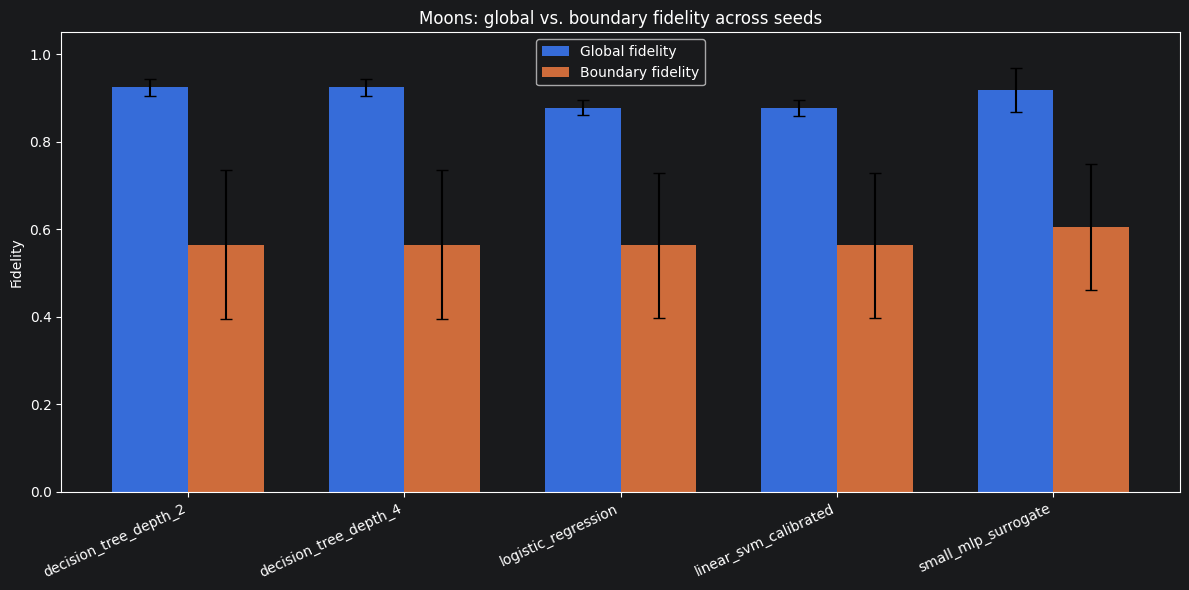

In [12]:
# Plot global vs. boundary fidelity by surrogate across seeds.
plot_df = results.copy()

fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(surrogates))
width = 0.35

ordered = summary.index.tolist()
global_means = [results.loc[results["surrogate"] == s, "global_fidelity"].mean() for s in ordered]
global_stds = [results.loc[results["surrogate"] == s, "global_fidelity"].std() for s in ordered]
boundary_means = [results.loc[results["surrogate"] == s, "boundary_fidelity"].mean() for s in ordered]
boundary_stds = [results.loc[results["surrogate"] == s, "boundary_fidelity"].std() for s in ordered]

ax.bar(positions - width / 2, global_means, width, yerr=global_stds, capsize=4, label="Global fidelity")
ax.bar(positions + width / 2, boundary_means, width, yerr=boundary_stds, capsize=4, label="Boundary fidelity")

ax.set_xticks(positions)
ax.set_xticklabels(ordered, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Fidelity")
ax.set_title("Moons: global vs. boundary fidelity across seeds")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# Threshold sensitivity across seeds and surrogates.
eps_values = [0.05, 0.10, 0.15, 0.20]
threshold_rows = []

for seed in seeds:
    print(f"Threshold sweep seed {seed}...")
    for surrogate_name in surrogates:
        for eps in eps_values:
            row = run_one(seed=seed, surrogate_name=surrogate_name, eps=eps, noise=0.25)
            threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows)
threshold_results


Threshold sweep seed 0...
Threshold sweep seed 1...
Threshold sweep seed 2...
Threshold sweep seed 3...
Threshold sweep seed 4...
Threshold sweep seed 5...
Threshold sweep seed 6...
Threshold sweep seed 7...
Threshold sweep seed 8...
Threshold sweep seed 9...


,teacher_task_accuracy,surrogate_task_accuracy,global_fidelity,probability_mse,n_boundary_points,boundary_fraction,boundary_fidelity,boundary_task_accuracy,nonboundary_fidelity,boundary_gap,seed,surrogate,eps,noise
0,0.914286,0.840000,0.883810,0.059355,7,0.013333,0.714286,0.142857,0.886100,0.169524,0,logistic_regression,0.05,0.25
1,0.914286,0.840000,0.883810,0.059355,10,0.019048,0.800000,0.300000,0.885437,0.083810,0,logistic_regression,0.10,0.25
2,0.914286,0.840000,0.883810,0.059355,16,0.030476,0.750000,0.312500,0.888016,0.133810,0,logistic_regression,0.15,0.25
3,0.914286,0.840000,0.883810,0.059355,28,0.053333,0.607143,0.500000,0.899396,0.276667,0,logistic_regression,0.20,0.25
4,0.914286,0.840000,0.883810,0.059148,7,0.013333,0.714286,0.142857,0.886100,0.169524,0,linear_svm_calibrated,0.05,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.927619,0.891429,0.925714,0.037866,26,0.049524,0.615385,0.538462,0.941884,0.310330,9,decision_tree_depth_4,0.20,0.25
196,0.927619,0.851429,0.874286,0.064293,3,0.005714,1.000000,0.333333,0.873563,-0.125714,9,small_mlp_surrogate,0.05,0.25
197,0.927619,0.851429,0.874286,0.064293,8,0.015238,0.750000,0.375000,0.876209,0.124286,9,small_mlp_surrogate,0.10,0.25
198,0.927619,0.851429,0.874286,0.064293,14,0.026667,0.571429,0.428571,0.882583,0.302857,9,small_mlp_surrogate,0.15,0.25


In [14]:
threshold_summary = (
    threshold_results
    .groupby(["surrogate", "eps"])
    .agg(
        global_fidelity_mean=("global_fidelity", "mean"),
        boundary_fidelity_mean=("boundary_fidelity", "mean"),
        nonboundary_fidelity_mean=("nonboundary_fidelity", "mean"),
        boundary_gap_mean=("boundary_gap", "mean"),
        boundary_fraction_mean=("boundary_fraction", "mean"),
    )
    .reset_index()
)

threshold_summary


,surrogate,eps,global_fidelity_mean,boundary_fidelity_mean,nonboundary_fidelity_mean,boundary_gap_mean,boundary_fraction_mean
0,decision_tree_depth_2,0.05,0.924000,0.613056,0.928104,0.310944,0.012000
1,decision_tree_depth_2,0.10,0.924000,0.564552,0.932212,0.359448,0.022286
2,decision_tree_depth_2,0.15,0.924000,0.593337,0.935535,0.330663,0.034286
3,decision_tree_depth_2,0.20,0.924000,0.590186,0.941112,0.333814,0.050095
4,decision_tree_depth_4,0.05,0.924000,0.613056,0.928104,0.310944,0.012000
5,decision_tree_depth_4,0.10,0.924000,0.564552,0.932212,0.359448,0.022286
6,decision_tree_depth_4,0.15,0.924000,0.593337,0.935535,0.330663,0.034286
7,decision_tree_depth_4,0.20,0.924000,0.590186,0.941112,0.333814,0.050095
8,linear_svm_calibrated,0.05,0.877333,0.557897,0.881249,0.319437,0.012000
9,linear_svm_calibrated,0.10,0.877333,0.562910,0.884284,0.314423,0.022286


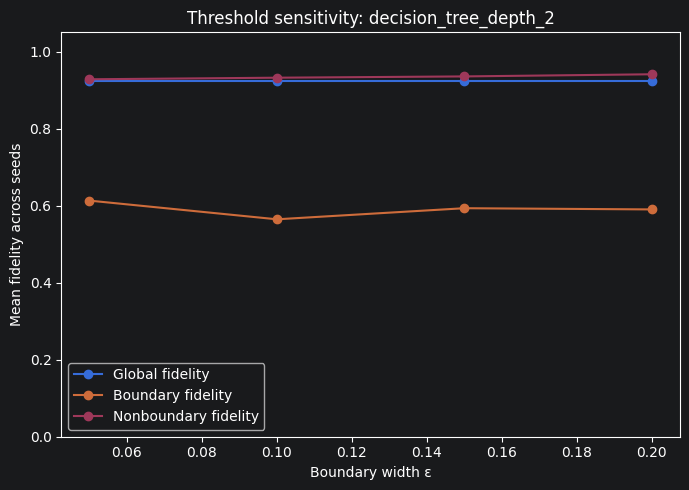

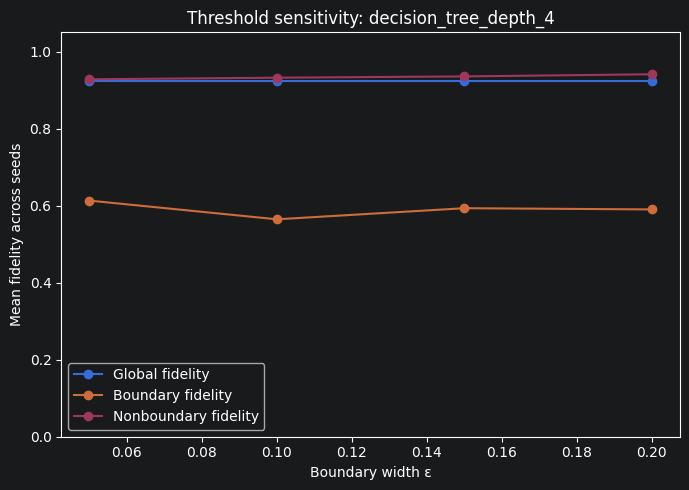

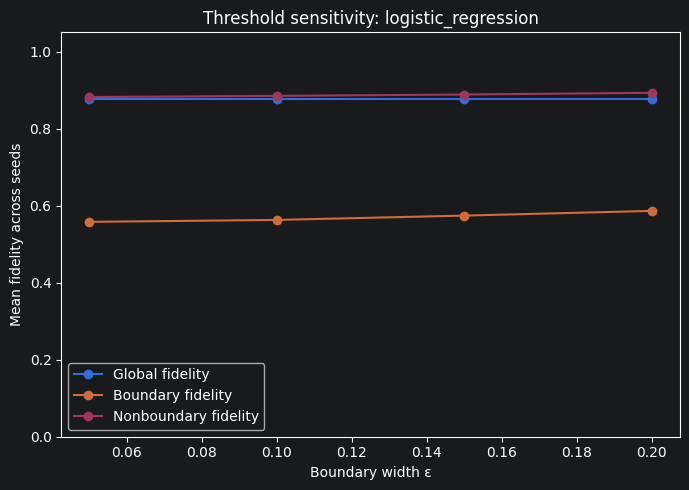

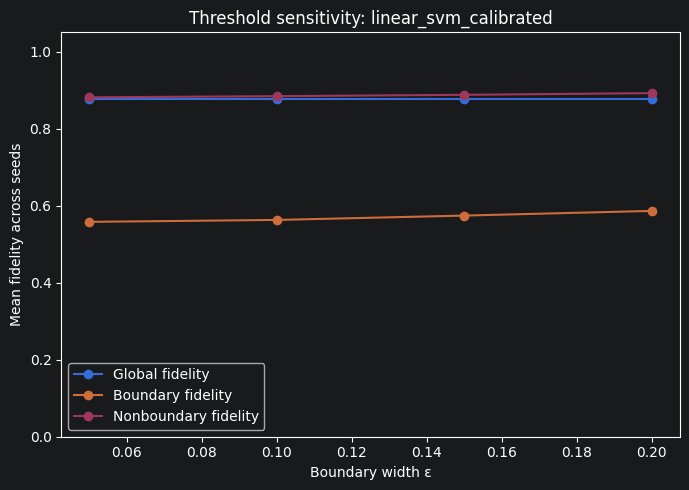

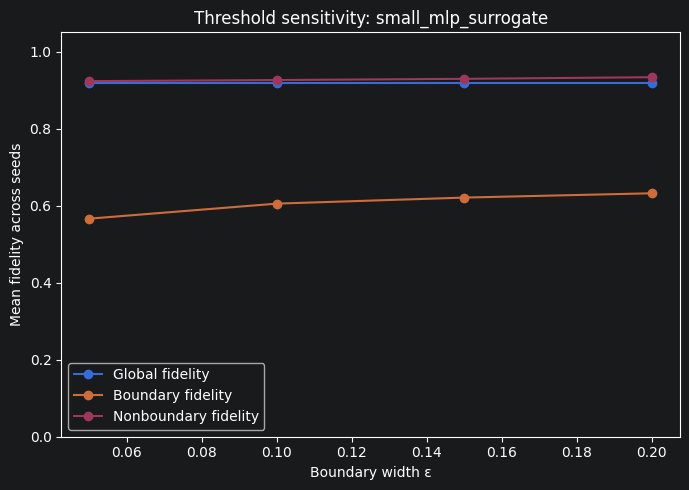

In [15]:
# Plot threshold sensitivity for each surrogate.
for surrogate_name in ordered:
    subset = threshold_summary[threshold_summary["surrogate"] == surrogate_name]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(subset["eps"], subset["global_fidelity_mean"], marker="o", label="Global fidelity")
    ax.plot(subset["eps"], subset["boundary_fidelity_mean"], marker="o", label="Boundary fidelity")
    ax.plot(subset["eps"], subset["nonboundary_fidelity_mean"], marker="o", label="Nonboundary fidelity")

    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Boundary width ε")
    ax.set_ylabel("Mean fidelity across seeds")
    ax.set_title(f"Threshold sensitivity: {surrogate_name}")
    ax.legend()
    plt.tight_layout()
    plt.show()


In [16]:
threshold_results.to_csv("moons_threshold_sensitivity_results.csv", index=False)
threshold_summary.to_csv("moons_threshold_sensitivity_summary.csv", index=False)

print("Saved:")
print("- moons_threshold_sensitivity_results.csv")
print("- moons_threshold_sensitivity_summary.csv")


Saved:
- moons_threshold_sensitivity_results.csv
- moons_threshold_sensitivity_summary.csv
